<a href="https://colab.research.google.com/github/Sunnik-Chatterjee/AP-Lab/blob/main/2328052_Lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Techniques — Comprehensive Notebook
### Datasets: La Liga Matches (laliga_matches.csv)
---

## Section 1 — Setup
Install required libraries and import all dependencies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
)
from sklearn.tree  import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm   import SVR

sns.set_theme(style='whitegrid', palette='muted')
print('All libraries imported.')


All libraries imported.


## Section 2 — Load Dataset



In [ ]:
def load_dataset():
    """laliga_matches.csv."""
    for fname in ['laliga_matches.csv']:
        try:
            df = pd.read_csv(fname)
            print(f'Loaded: {fname}  |  shape: {df.shape}')
            return df, fname
        except FileNotFoundError:
            pass
    raise FileNotFoundError(
        'Neither results.csv nor laliga_matches.csv found. '
        'Please upload one of them to the Colab working directory.'
    )

df_raw, dataset_name = load_dataset()


Loaded: laliga_matches.csv  |  shape: (4700, 29)


In [ ]:
print(f'\n--- Dataset: {dataset_name} ---')
print(f'Shape : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()



--- Dataset: laliga_matches.csv ---
Shape : 4700 rows × 29 columns
Columns: ['Unnamed: 0', 'date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain', 'formation', 'opp formation', 'referee', 'match report', 'notes', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team']


,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,...,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2025-08-16,19:30,La Liga,Matchweek 1,Sat,Away,W,3.0,0.0,...,Match Report,NaN,24.0,8.0,18.9,1.0,0,0,2025,Barcelona
1,1,2025-08-23,21:30,La Liga,Matchweek 2,Sat,Away,W,3.0,2.0,...,Match Report,NaN,26.0,10.0,17.0,1.0,0,0,2025,Barcelona
2,2,2025-08-31,21:30,La Liga,Matchweek 3,Sun,Away,D,1.0,1.0,...,Match Report,NaN,11.0,2.0,20.3,0.0,1,1,2025,Barcelona
3,3,2025-09-14,21:00,La Liga,Matchweek 4,Sun,Home,W,6.0,0.0,...,Match Report,NaN,24.0,10.0,18.4,0.0,0,0,2025,Barcelona
4,5,2025-09-21,21:00,La Liga,Matchweek 5,Sun,Home,W,3.0,0.0,...,Match Report,NaN,16.0,7.0,18.2,2.0,0,0,2025,Barcelona


## Section 3 — Data Preprocessing
- Select only numerical columns
- Apply **mean imputation** for missing values
- Last numerical column is used as the **target variable (y)**; all others are **features (X)**


In [ ]:
# Select numerical columns only
num_df = df_raw.select_dtypes(include=np.number).copy()
print(f'Numerical columns ({len(num_df.columns)}): {num_df.columns.tolist()}')

# Remove columns that are entirely NaN
num_df = num_df.dropna(axis=1, how='all')

# Replace infinite values with NaN
num_df = num_df.replace([np.inf, -np.inf], np.nan)

# Mean imputation
num_df = num_df.fillna(num_df.mean())

print(f'Missing values after imputation: {num_df.isnull().sum().sum()}')

# Feature / target split
if num_df.shape[1] < 2:
    raise ValueError('Dataset must have at least 2 numerical columns.')

X = num_df.iloc[:, :-1]
y = num_df.iloc[:, -1]

print(f'\nFeatures (X) shape : {X.shape}')
print(f'Target   (y) name  : {y.name}')
print(f'Target   (y) shape : {y.shape}')

# Final safety check
print("\nRemaining NaN in X:", X.isnull().sum().sum())
print("Remaining NaN in y:", y.isnull().sum())

Numerical columns (15): ['Unnamed: 0', 'gf', 'ga', 'xg', 'xga', 'poss', 'attendance', 'notes', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season']
Missing values after imputation: 0

Features (X) shape : (4700, 13)
Target   (y) name  : season
Target   (y) shape : (4700,)

Remaining NaN in X: 0
Remaining NaN in y: 0


## Section 4 — Train-Test Split
Split the data into **80 % training** and **20 % testing** sets.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Training set : X={X_train.shape}  y={y_train.shape}')
print(f'Testing  set : X={X_test.shape}   y={y_test.shape}')


Training set : X=(3760, 13)  y=(3760,)
Testing  set : X=(940, 13)   y=(940,)


## Section 5 — Feature Scaling
Apply **StandardScaler** to normalise features (required for SVR, Ridge/Lasso etc.).


In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('StandardScaler applied.')
print(f'Mean  (train) ≈ {X_train_sc.mean(axis=0).round(4)}')
print(f'Std   (train) ≈ {X_train_sc.std(axis=0).round(4)}')


StandardScaler applied.
Mean  (train) ≈ [ 0.  0. -0.  0.  0.  0.  0.  0.  0. -0. -0.  0.  0.]
Std   (train) ≈ [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Section 6 — 10 Regression Models
Each model is trained on the appropriate version of the training set (raw or scaled), predictions are made, and evaluation metrics are computed.


In [ ]:
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te):

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mse  = mean_squared_error(y_te, preds)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, preds)

    results[name] = {
        "Model": name,
        "preds": preds,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"{name:<35}  MSE={mse:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")

print(f"{'Model':<35}  MSE        MAE        RMSE       R2")
print("-"*85)


# 1 Linear Regression
evaluate(
    "1 Linear Regression",
    LinearRegression(),
    X_train, X_test, y_train, y_test
)


# 2 Polynomial Regression
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

evaluate(
    "2 Polynomial Regression",
    poly_model,
    X_train, X_test, y_train, y_test
)


# 3 Stepwise Regression
lr_base = LinearRegression()

sfs = SequentialFeatureSelector(
    lr_base,
    n_features_to_select=max(1, X_train.shape[1]//2),
    direction="forward",
    cv=3
)

sfs.fit(X_train_sc, y_train)

X_train_sfs = sfs.transform(X_train_sc)
X_test_sfs  = sfs.transform(X_test_sc)

evaluate(
    "3 Stepwise Regression",
    LinearRegression(),
    X_train_sfs, X_test_sfs, y_train, y_test
)


# 4 Decision Tree
evaluate(
    "4 Decision Tree Regression",
    DecisionTreeRegressor(max_depth=5, random_state=42),
    X_train, X_test, y_train, y_test
)


# 5 Random Forest
evaluate(
    "5 Random Forest Regression",
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test
)


# 6 Support Vector Regression
evaluate(
    "6 Support Vector Regression",
    SVR(kernel="rbf"),
    X_train_sc, X_test_sc, y_train, y_test
)


# 7 Ridge Regression
evaluate(
    "7 Ridge Regression",
    Ridge(alpha=1.0),
    X_train_sc, X_test_sc, y_train, y_test
)


# 8 Lasso Regression
evaluate(
    "8 Lasso Regression",
    Lasso(alpha=0.01, max_iter=10000),
    X_train_sc, X_test_sc, y_train, y_test
)


# 9 ElasticNet Regression
evaluate(
    "9 ElasticNet Regression",
    ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    X_train_sc, X_test_sc, y_train, y_test
)


# 10 Bayesian Ridge
evaluate(
    "10 Bayesian Ridge Regression",
    BayesianRidge(),
    X_train_sc, X_test_sc, y_train, y_test
)

print("\nAll models trained.")

Model                                MSE        MAE        RMSE       R2
-------------------------------------------------------------------------------------
1 Linear Regression                  MSE=3.2174  MAE=1.5488  RMSE=1.7937  R2=0.0267
2 Polynomial Regression              MSE=3.2475  MAE=1.5502  RMSE=1.8021  R2=0.0176
3 Stepwise Regression                MSE=3.2227  MAE=1.5539  RMSE=1.7952  R2=0.0251
4 Decision Tree Regression           MSE=2.3491  MAE=1.1678  RMSE=1.5327  R2=0.2894
5 Random Forest Regression           MSE=2.2806  MAE=1.1449  RMSE=1.5102  R2=0.3101
6 Support Vector Regression          MSE=3.2209  MAE=1.4964  RMSE=1.7947  R2=0.0256
7 Ridge Regression                   MSE=3.2174  MAE=1.5489  RMSE=1.7937  R2=0.0267
8 Lasso Regression                   MSE=3.2193  MAE=1.5523  RMSE=1.7942  R2=0.0261
9 ElasticNet Regression              MSE=3.2175  MAE=1.5505  RMSE=1.7937  R2=0.0267
10 Bayesian Ridge Regression         MSE=3.2194  MAE=1.5521  RMSE=1.7943  R2=0.0261



## Section 7 — Evaluation Metrics
Metric definitions:
- **MSE** — Mean Squared Error
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **R² Score** — Coefficient of Determination (higher = better)


In [ ]:
print('Evaluation Metrics Summary')
print('=' * 75)
for name, m in results.items():
    print(f"\n{name}")
    print(f"  MSE  : {m['MSE']}")
    print(f"  MAE  : {m['MAE']}")
    print(f"  RMSE : {m['RMSE']}")
    print(f"  R²   : {m['R2']}")


Evaluation Metrics Summary

1 Linear Regression
  MSE  : 3.2174067695926296
  MAE  : 1.54884535474863
  RMSE : 1.7937131235492005
  R²   : 0.02667422794147012

2 Polynomial Regression
  MSE  : 3.2475319757940353
  MAE  : 1.5502386542429165
  RMSE : 1.8020910009747109
  R²   : 0.017560789174099645

3 Stepwise Regression
  MSE  : 3.222668155347977
  MAE  : 1.5538506810474162
  RMSE : 1.795179142968182
  R²   : 0.025082560266490472

4 Decision Tree Regression
  MSE  : 2.349061419469574
  MAE  : 1.1677727634725308
  RMSE : 1.532664809888181
  R²   : 0.28936495026781417

5 Random Forest Regression
  MSE  : 2.280612234042547
  MAE  : 1.144861702127657
  RMSE : 1.510169604396323
  R²   : 0.31007211010914637

6 Support Vector Regression
  MSE  : 3.2208684073726834
  MAE  : 1.4963899139591972
  RMSE : 1.7946778004345747
  R²   : 0.025627017717167355

7 Ridge Regression
  MSE  : 3.21740396227444
  MAE  : 1.5488535227558213
  RMSE : 1.7937123410052238
  R²   : 0.026675077207770403

8 Lasso Regres

## Section 8 — Model Comparison Table
All 10 models ranked by **R² Score** (descending).


In [ ]:
comparison = pd.DataFrame([
    {'Model': name, 'MSE': m['MSE'], 'MAE': m['MAE'],
     'RMSE': m['RMSE'], 'R2 Score': m['R2']}
    for name, m in results.items()
])
comparison = comparison.sort_values('R2 Score', ascending=False).reset_index(drop=True)
comparison.index += 1
print(comparison.to_string())
comparison


                           Model       MSE       MAE      RMSE  R2 Score
1     5 Random Forest Regression  2.280612  1.144862  1.510170  0.310072
2     4 Decision Tree Regression  2.349061  1.167773  1.532665  0.289365
3             7 Ridge Regression  3.217404  1.548854  1.793712  0.026675
4            1 Linear Regression  3.217407  1.548845  1.793713  0.026674
5        9 ElasticNet Regression  3.217461  1.550535  1.793728  0.026658
6             8 Lasso Regression  3.219285  1.552264  1.794237  0.026106
7   10 Bayesian Ridge Regression  3.219420  1.552083  1.794274  0.026065
8    6 Support Vector Regression  3.220868  1.496390  1.794678  0.025627
9          3 Stepwise Regression  3.222668  1.553851  1.795179  0.025083
10       2 Polynomial Regression  3.247532  1.550239  1.802091  0.017561


,Model,MSE,MAE,RMSE,R2 Score
1,5 Random Forest Regression,2.280612,1.144862,1.510170,0.310072
2,4 Decision Tree Regression,2.349061,1.167773,1.532665,0.289365
3,7 Ridge Regression,3.217404,1.548854,1.793712,0.026675
4,1 Linear Regression,3.217407,1.548845,1.793713,0.026674
5,9 ElasticNet Regression,3.217461,1.550535,1.793728,0.026658
6,8 Lasso Regression,3.219285,1.552264,1.794237,0.026106
7,10 Bayesian Ridge Regression,3.219420,1.552083,1.794274,0.026065
8,6 Support Vector Regression,3.220868,1.496390,1.794678,0.025627
9,3 Stepwise Regression,3.222668,1.553851,1.795179,0.025083
10,2 Polynomial Regression,3.247532,1.550239,1.802091,0.017561


## Section 9 — Visualization
Three plots:
1. **Actual vs Predicted** — scatter plot for each model
2. **R² Score Comparison** — bar chart across all models
3. **Residual Error Plot** — prediction error distribution


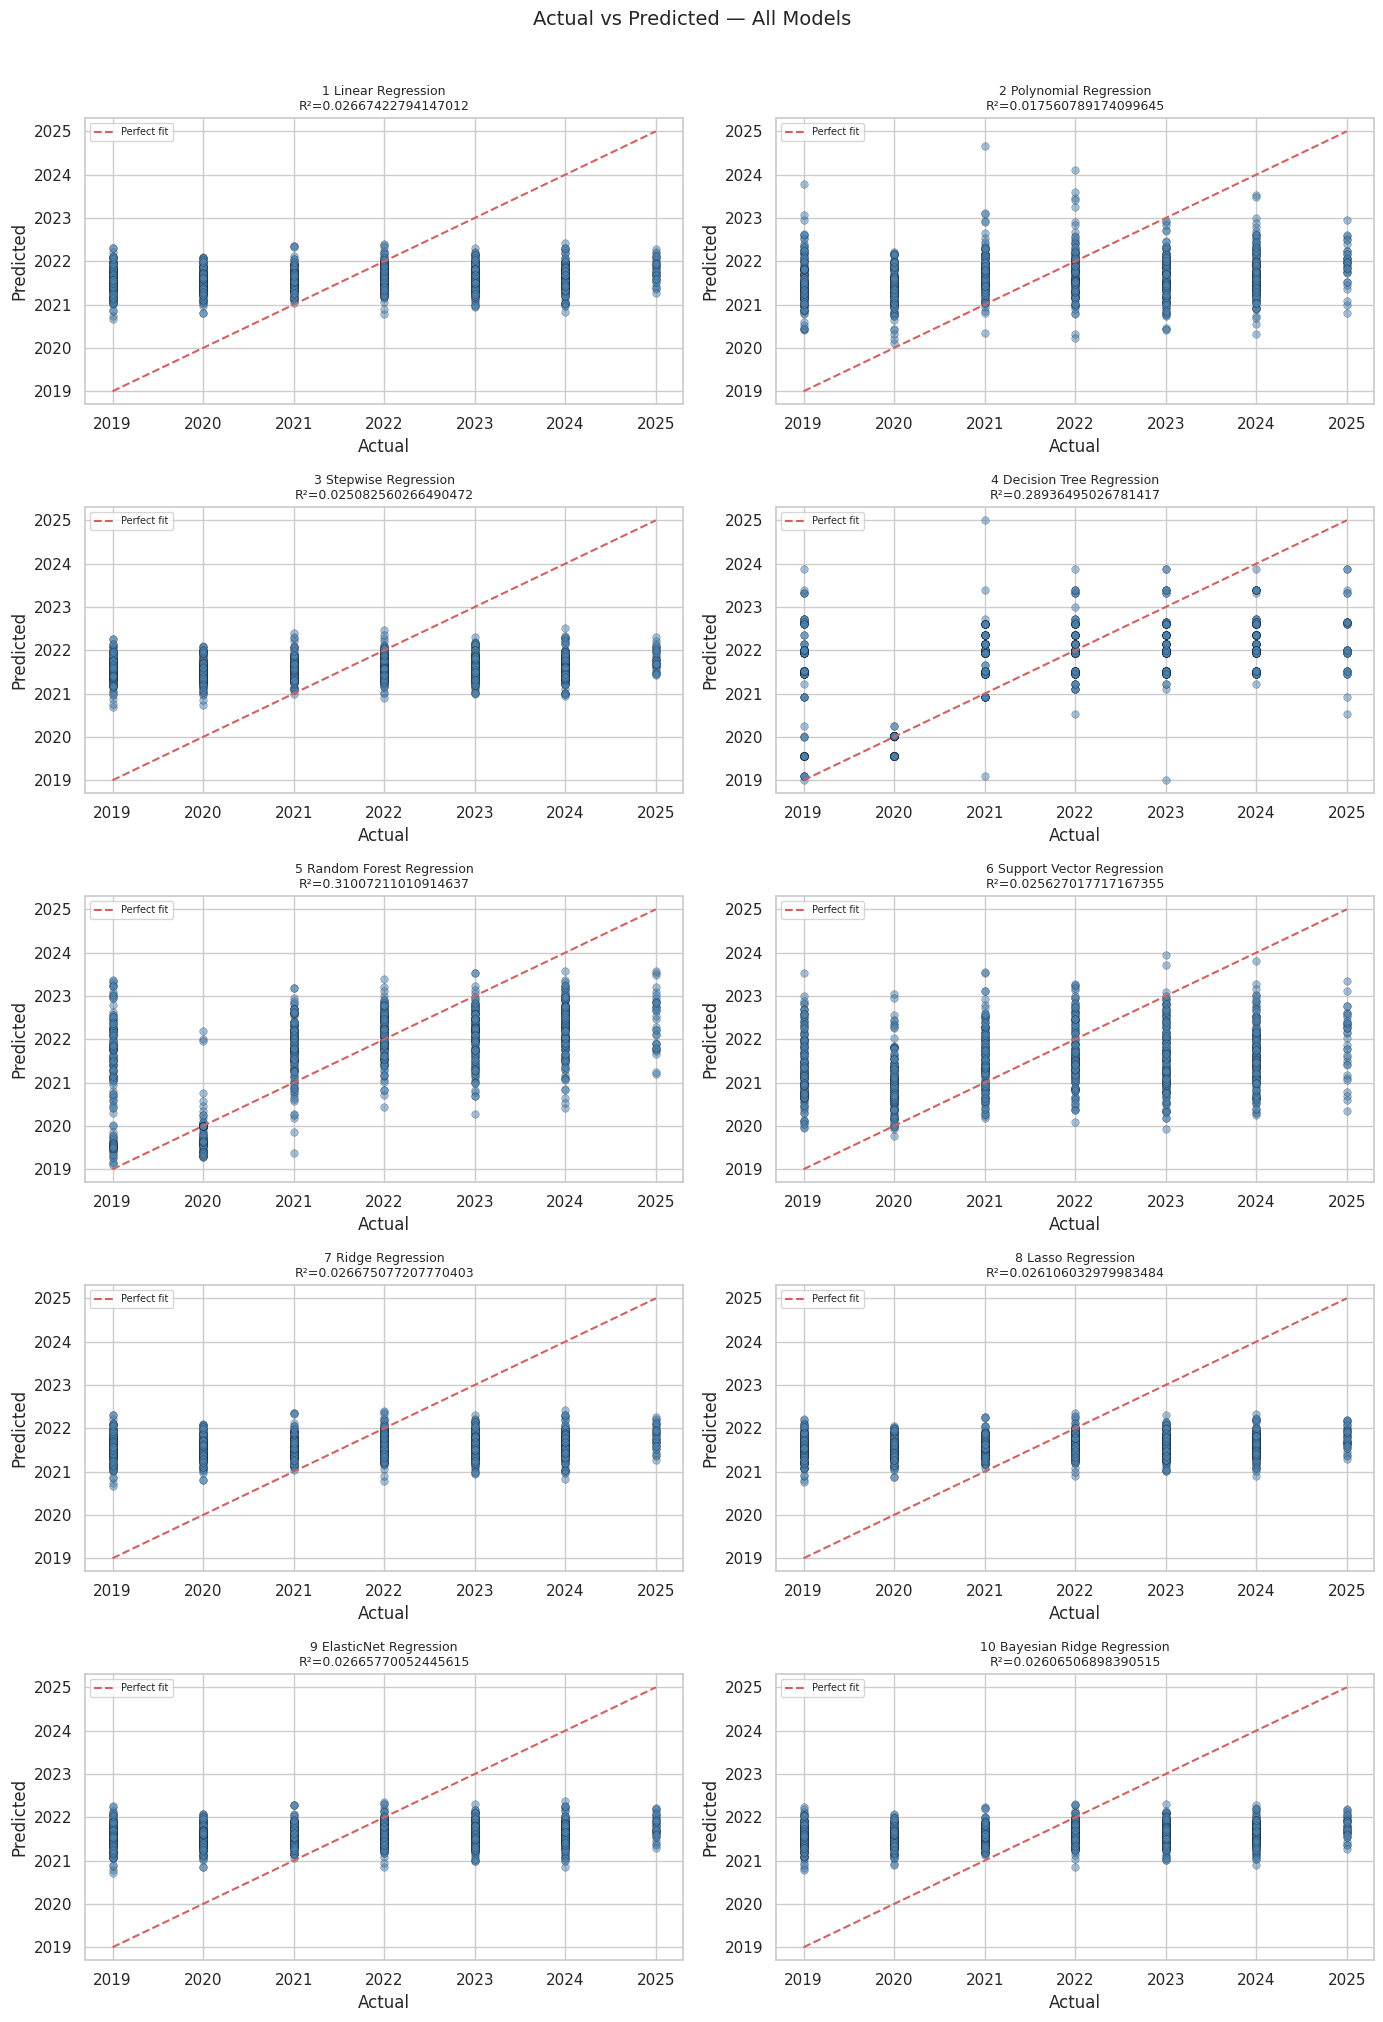

In [ ]:
# Plot 1: Actual vs Predicted — grid of scatter plots
n_models = len(results)
cols_per_row = 2
rows = (n_models + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, rows * 4))
axes = axes.flatten()

for i, (name, m) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(y_test, m['preds'], alpha=0.5, edgecolors='k',
               linewidths=0.3, color='steelblue', s=30)
    lims = [min(y_test.min(), np.min(m['preds'])),
            max(y_test.max(), np.max(m['preds']))]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(f"{name}\nR²={m['R2']}", fontsize=9)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('reg_actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()


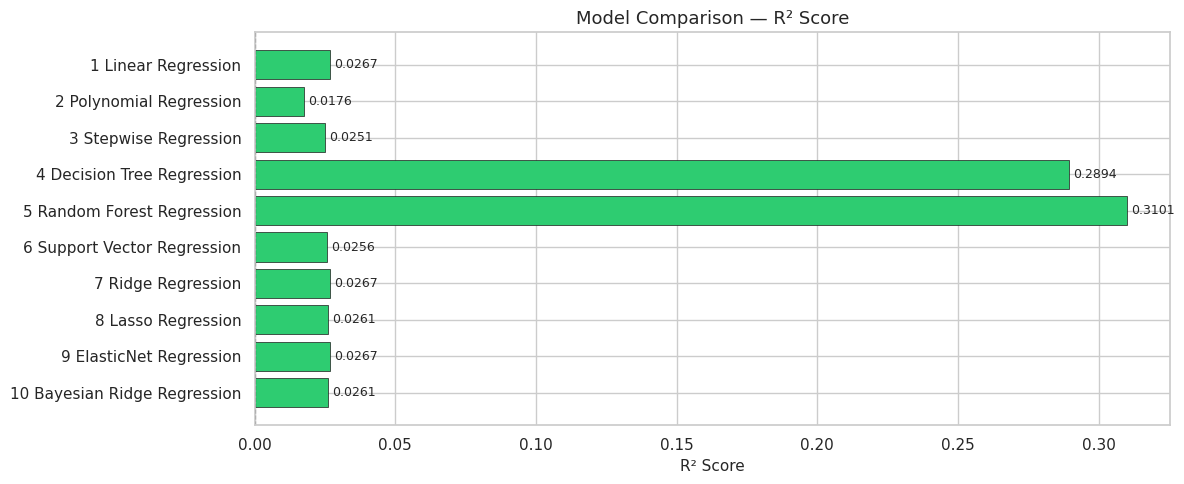

In [ ]:
# Plot 2: R² Score comparison bar chart
model_names  = [n.split('. ',1)[1] if '. ' in n else n for n in results.keys()]
r2_scores    = [m['R2'] for m in results.values()]
colors       = ['#2ecc71' if r > 0 else '#e74c3c' for r in r2_scores]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(model_names, r2_scores, color=colors, edgecolor='k', linewidth=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('R² Score', fontsize=11)
ax.set_title('Model Comparison — R² Score', fontsize=13)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('reg_r2_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


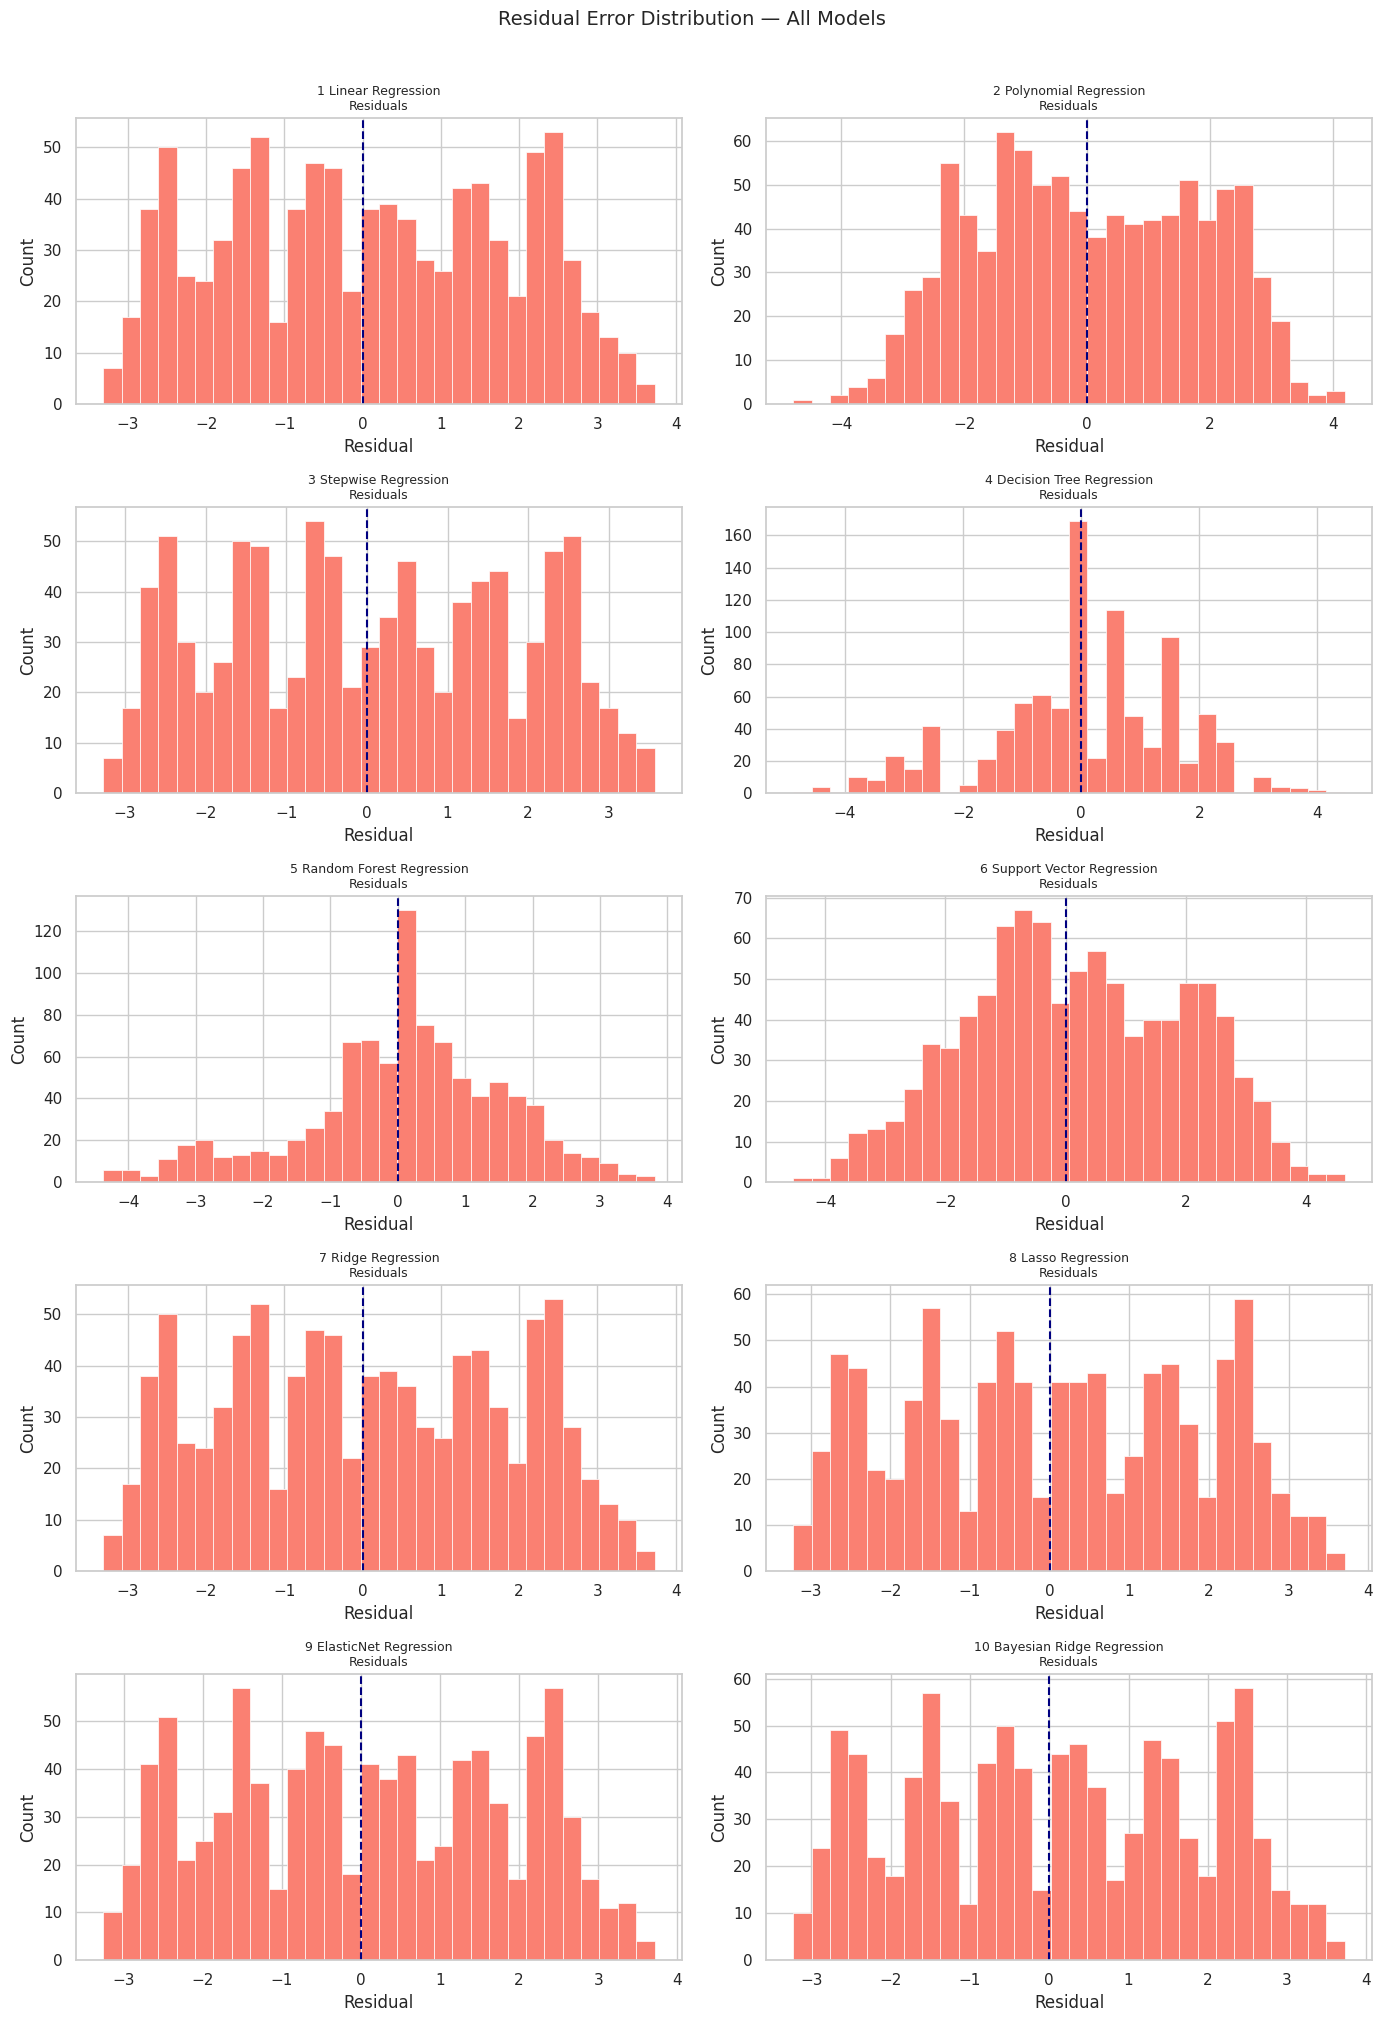

In [ ]:
# Plot 3: Residual error distribution for each model
fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, rows * 4))
axes = axes.flatten()

for i, (name, m) in enumerate(results.items()):
    residuals = np.array(y_test) - np.array(m['preds'])
    ax = axes[i]
    ax.hist(residuals, bins=30, color='salmon', edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='navy', linestyle='--', lw=1.5)
    ax.set_title(f"{name}\nResiduals", fontsize=9)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Count')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Residual Error Distribution — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('reg_residuals.png', bbox_inches='tight', dpi=150)
plt.show()


## Section 10 — Conclusion
Identify and print the best performing regression model.


In [ ]:
best_idx  = comparison['R2 Score'].idxmax()
best_row  = comparison.loc[best_idx]

print('=' * 60)
print('          CONCLUSION')
print('=' * 60)
print(f"Dataset          : {dataset_name}")
print(f"Total models     : {len(results)}")
print()
print(f"🏆  Best Model    : {best_row['Model']}")
print(f"   R² Score      : {best_row['R2 Score']}")
print(f"   MSE           : {best_row['MSE']}")
print(f"   MAE           : {best_row['MAE']}")
print(f"   RMSE          : {best_row['RMSE']}")
print()
print('Full ranking (by R² Score):')
for _, row in comparison.iterrows():
    medal = '🥇' if row['Model'] == best_row['Model'] else '  '
    print(f"  {medal} {row['Model']:<42s}  R²={row['R2 Score']}")
print('=' * 60)


          CONCLUSION
Dataset          : laliga_matches.csv
Total models     : 10

🏆  Best Model    : 5 Random Forest Regression
   R² Score      : 0.31007211010914637
   MSE           : 2.280612234042547
   MAE           : 1.144861702127657
   RMSE          : 1.510169604396323

Full ranking (by R² Score):
  🥇 5 Random Forest Regression                  R²=0.31007211010914637
     4 Decision Tree Regression                  R²=0.28936495026781417
     7 Ridge Regression                          R²=0.026675077207770403
     1 Linear Regression                         R²=0.02667422794147012
     9 ElasticNet Regression                     R²=0.02665770052445615
     8 Lasso Regression                          R²=0.026106032979983484
     10 Bayesian Ridge Regression                R²=0.02606506898390515
     6 Support Vector Regression                 R²=0.025627017717167355
     3 Stepwise Regression                       R²=0.025082560266490472
     2 Polynomial Regression              